# Calories Expendition Predict
1. Data overview
3. Remove outliers
4. Data transformer
5. Model build
6. Parameters tunning
7. Submit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Custom code
import build, log

%xmode Context

Exception reporting mode: Context


## 1. Data overview

In [2]:
# Folder path
folder_dir = 'D:/data/CaloriesPrediction/'

In [3]:
df = pd.read_csv(os.path.join(folder_dir, 'train.csv'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


## Feature selection

In [4]:
df_sample = df.sample(n=10000, random_state=42)

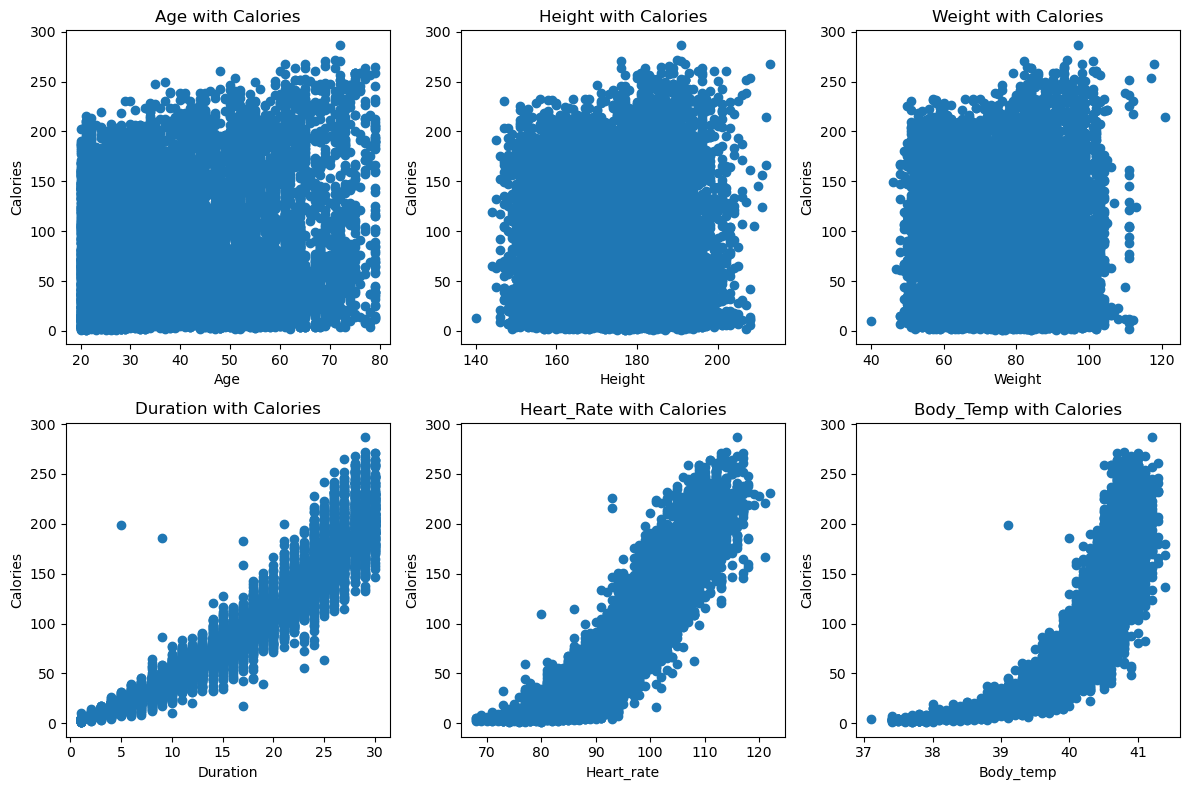

In [5]:
# View Scatter plot of each features to the label
import matplotlib.pyplot as plt

num_cols = df.drop(['id', 'Calories'], axis=1).select_dtypes(include='number').columns

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for i, col in enumerate(num_cols):
    axs[i].scatter(df_sample[col], df_sample['Calories'])
    axs[i].set_xlabel(col.capitalize())
    axs[i].set_ylabel('Calories')
    axs[i].set_title(f'{col} with Calories')

plt.tight_layout()
plt.show()

While Duration, Heart_rate, Body_temp is correlated witht he label, other Age, Height, Weight is seem random scattered, but we shouldn't remove them yet, let's ask ChatGPT for hint.

And ChatGPT do it well, it recommends BMI calculation

## Feature Extraction

In [6]:
df['temp_diff'] = df['Body_Temp'] - 37
df['very_short_duration'] = df['Duration'] <= 2
df['short_duration'] = df['Duration'] < 5

## Features scaling

## Model building

In [7]:
df.drop('id', axis=1, inplace=True, errors='ignore')

In [8]:
%%time

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
import numpy as np


cat_features = ['Sex']
num_features = ['Duration', 'Heart_Rate', 'Body_Temp', 'temp_diff']

cat_preprocessing = OneHotEncoder(drop='if_binary', dtype=int)

def feature_extract(df) :
    df['Effort'] = df['Duration'] * df['Body_Temp']
    return df
    
    
num_preprocessing = Pipeline(steps=[
    ('fea_ext', FunctionTransformer(feature_extract, validate=False)),
    # ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_preprocessing, cat_features),
    ('num', num_preprocessing, num_features)
])

models = {
    'LinearRegression': LinearRegression(),
    'LightGBM': lgb.LGBMRegressor(objective='poisson', n_estimators=100, learning_rate=0.01, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.01, max_depth=3, random_state=42)
}

X = df.drop('Calories', axis=1)
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    model = pipeline.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.maximum(y_pred, 0)
    msle = mean_squared_log_error(y_test, y_pred)
    print(f'Model {name}, RMSLE: {np.sqrt(msle)}')

Model LinearRegression, RMSLE: 0.4399492548178576
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 422
[LightGBM] [Info] Number of data points in the train set: 562500, number of used features: 6
[LightGBM] [Info] Start training from score 4.480909
Model LightGBM, RMSLE: 0.7890804234106397
Model XGBoost, RMSLE: 0.6195652169495272
CPU times: total: 16.6 s
Wall time: 2.71 s


## Submission

In [9]:
df_submission = pd.read_csv(os.path.join(folder_dir, 'sample_submission.csv'))
df_submission

,id,Calories
0,750000,88.283
1,750001,88.283
2,750002,88.283
3,750003,88.283
4,750004,88.283
...,...,...
249995,999995,88.283
249996,999996,88.283
249997,999997,88.283
249998,999998,88.283
